# Data Import and Processing

**Notebook 1: Obtaining Data**

> **Lecturer version:** This copy contains completed code and sample reference answers for teaching use. Students should receive the scaffolded version instead.


## What you will learn

By the end of this notebook, you should be able to:

- explain why datasets are needed before data analysis or machine learning
- run a provided Python script to download data automatically
- create a folder and download a dataset using Python
- explain what a CSV file is
- import a dataset into a Pandas DataFrame
- identify when a dataset is missing column headers
- use basic Pandas functions such as `.head()`, `.info()`, and `.describe()`

## Before you start

You should already know how to:

- run cells in a Jupyter notebook
- create and use simple Python variables
- read basic Python code

## Files used in this notebook

- `magic.py`
- `data/iris.data`
- `resources/PetalSepal1.png`

> **Tip:** Run the notebook from top to bottom. Some later cells depend on variables created earlier.

## 1. Data Import

Datasets are essential to any data science project. Before we can analyse data or train a machine learning model, the computer must be able to read the data correctly.

In this first part, you will try a ready-made script called `magic.py`. It will automatically download a file and plot a graph. This is a quick demonstration of how Python can help us automate data collection and setup.

Some common places to obtain public datasets are:

- [Kaggle](https://www.kaggle.com/)
- [UCI Machine Learning Repository](https://archive.ics.uci.edu/)

If your notebook has plotting issues in your environment, try commenting out the first line below.

Current working directory: /workspaces/AIML202607/Chp 1 M16 - Data Import and Processing

File has been downloaded!
Downloaded full file path: /workspaces/AIML202607/Chp 1 M16 - Data Import and Processing/Magic_Data/co2-mm-mlo.csv

Performing super difficult data analysis on co2-mm-mlo.csv..........


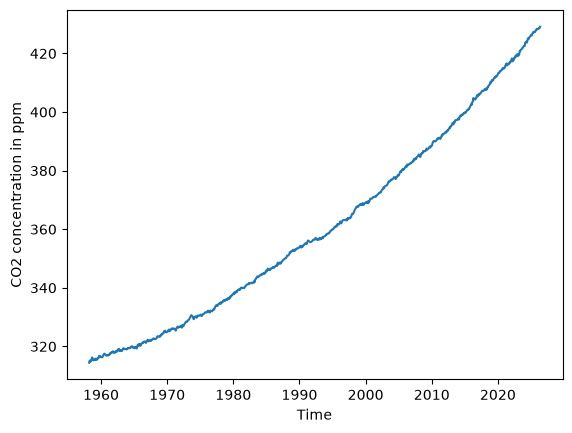

<Figure size 640x480 with 0 Axes>

In [1]:
%matplotlib inline
%run "magic.py"

After running the script, answer the question below.

**Question:** Without opening `magic.py` yet, where do you think the data was downloaded to? Use the printed output as your clue.

> **Checkpoint:** Your answer should mention the current working directory and the folder created by the script.

In [ ]:
# Reference answer:
# The script prints the current working directory and creates/uses a folder called Magic_Data.
# The downloaded CO2 file is saved as Magic_Data/co2-mm-mlo.csv relative to the notebook folder.


**Bonus thinking 1:** What do you observe from the figure? Any trends/patterns? 
> This is an observation question. You are not expected to give a perfect answer yet.

In [ ]:
# Reference answer:
# [For latest data from GitHub]
# The graph shows a clear trend of increasing CO2 levels over time, with some seasonal fluctuations. The x-axis is more readable, and the negative values are not present in the latest data.


Now, look into magic.py. Can you identify the code for reading a CSV file and plotting a line-graph from its data? Try completing the code below to read **co2-mm-mlo-old.csv** and plot a line-graph from its data.


Performing super difficult data analysis on co2-mm-mlo-old.csv..........


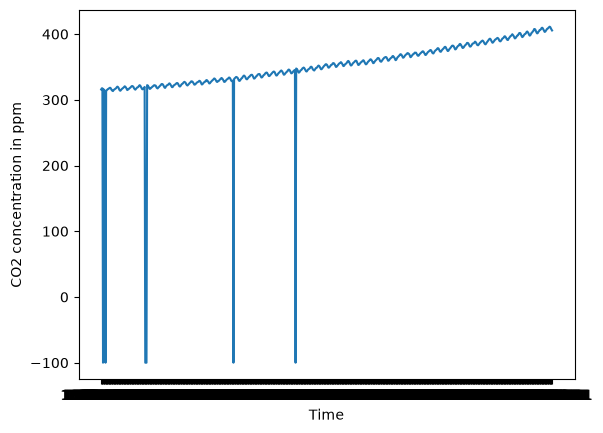

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# name of the csv file to be read
fn = "co2-mm-mlo-old.csv"
# join current working directory with the folder name and file name to get the full path of the file
path = os.path.join(os.getcwd(),"Magic_Data", fn)
print()
print(f"Performing super difficult data analysis on {fn}..........")
# read_csv() function takes the full path of the file as an argument and returns a DataFrame
carbon_dioxide = pd.read_csv(path)
# plotting date on x-axis and average CO2 concentration on y-axis
plt.plot(carbon_dioxide['Date'],carbon_dioxide['Average'])
plt.xlabel('Time')
plt.ylabel('CO2 concentration in ppm')
plt.show()

**Bonus thinking 2:** What do you observe from the second figure? Any abnormalies (look for any negative values and abnormalies in the X-axis) ?

> This is an observation question. You are not expected to give a perfect answer yet.

In [ ]:
# Reference answer:
# [For original data from MyConnexion]
# The graph is not very readable because there are too many date labels on the x-axis.
# The black lines on the x-axis are overcrowded date labels.
# Negative values may appear if some data values are used as placeholders or if the plot/data needs cleaning.

## 1.1 Downloading the Iris dataset

Now it is your turn to download a dataset. We will use the famous **Iris Flower dataset**.

Useful links:

- [Iris data file](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data)
- [Iris dataset background](https://en.wikipedia.org/wiki/Iris_flower_data_set)

Read the short description of the dataset before moving on.

Create a new folder to store the dataset, then write Python code to download the file automatically using `urllib.request.urlretrieve`. You may refer to the ideas used in `magic.py`, but try to write the code yourself.

> **Expected output:** A file named `iris.data` should be saved inside a `data` folder.

**Bonus:** Try to download the data using only 2 lines of code after you finish the guided version.

In [3]:
from pathlib import Path
import urllib.request

# Create a folder named data if it does not exist
data_folder = Path("data")
data_folder.mkdir(exist_ok=True)

# Download the Iris dataset into the data folder
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
output_file = data_folder / "iris.data"
urllib.request.urlretrieve(url, output_file)

print("Downloaded to:", output_file)

Downloaded to: data/iris.data


Well done. We now have our data downloaded. Next, we will explore a Python library called **Pandas** so that we can read and inspect the dataset.

## 1.2 Introduction to Pandas

Pandas is a Python library used to work with table-like data. In Pandas, this table is called a **DataFrame**. DataFrames make it easier to view, filter, summarise, and analyse data.

You may also look at these optional references if you want more explanation:

- [Intro article on DataFrames](https://www.datacamp.com/community/tutorials/pandas-tutorial-dataframe-python)
- [Intro video on Pandas](https://www.youtube.com/watch?v=dcqPhpY7tWk)

In your own words, answer the questions below.

In [ ]:
# Reference answers:
# 1. Install Pandas using pip install pandas. Use it by importing pandas as pd.
# 2. Pandas can read CSV, Excel, JSON, text, SQL tables, and other tabular formats.
# 3. A DataFrame is a table-like structure with rows and columns.
# 4. Columns can be accessed using df["column_name"]. Rows can be accessed using .loc[] or .iloc[].
# 5. Common functions include read_csv(), head(), info(), describe(), shape, and isnull().


Now let us start using Pandas. The first step is to import it.

> **Reminder:** The common short name for Pandas is `pd`.

In [4]:
import pandas as pd

After importing Pandas, we will read the Iris Flower dataset. The file is stored as a **CSV-style** file, which means the values are separated by commas.

## 1.2.1 Comma Separated Values (CSV) files

A CSV file stores values separated by commas or other separators. For example:

```
John,Mary,Harry,Luke
```

The commas tell the computer where one value ends and the next value begins.

Most CSV files use the `.csv` extension, but not all of them do. The Iris dataset is one example: it uses the extension `.data` even though its contents are CSV-style data.

Optional reading: [What is a CSV file?](https://www.howtogeek.com/348960/what-is-a-csv-file-and-how-do-i-open-it/)

In [ ]:
# Reference answer:
# A CSV file stores data as text separated by commas.
# Each line usually represents one row.
# CSV files are commonly used to store datasets.
# Pandas can read CSV-style files using pd.read_csv().


**Bonus thinking:** If a file does not end with `.csv`, how can you still tell whether it is CSV-style data? Which Python function might help you read it?

In [ ]:
# Reference answer:
# We can open the file in a text editor and check whether values are separated by commas.
# We can also try reading the file using pd.read_csv().


## 1.2.2 Iris Flower dataset

Now open the Iris dataset using `pd.read_csv()` and save it into a variable called `df`. Then print the first 5 rows.

> **Expected output:** You should see that something looks unusual about the column names. That is part of the activity.

In [5]:
df = pd.read_csv("./data/iris.data")
print(df.head())

   5.1  3.5  1.4  0.2  Iris-setosa
0  4.9  3.0  1.4  0.2  Iris-setosa
1  4.7  3.2  1.3  0.2  Iris-setosa
2  4.6  3.1  1.5  0.2  Iris-setosa
3  5.0  3.6  1.4  0.2  Iris-setosa
4  5.4  3.9  1.7  0.4  Iris-setosa


Did you notice that the dataframe is missing proper column headers? This happens because the original file does not include column names.

We can find the correct names from the Iris dataset description file:

- [Iris names file](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.names)

Look under the attribute information and write the required column names below.

In [ ]:
# Reference answer:
# 1. sepal_length
# 2. sepal_width
# 3. petal_length
# 4. petal_width
# 5. class / species


The picture below shows the parts of a flower used in the dataset: `sepal_length`, `sepal_width`, `petal_length`, and `petal_width`.

<img src="./resources/PetalSepal1.png">

Now let us load the data again properly. This time, tell Pandas that the file has **no header row**, then add the correct column names.

The first 2 names are already provided. Complete the list and display the top 5 rows again.

> **Checkpoint:** Your final table should have 5 named columns and the species name should appear as data, not as a header.

In [6]:
df = pd.read_csv("./data/iris.data", header=None)
print(df.head())

names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
df.columns = names

print(df.head())

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


With the correct labels in place, you can now use Pandas to inspect the dataset.

Use the following functions to find out:

- the number of rows and columns
- the data type of each column
- whether there are missing values
- basic statistics for the numeric columns

> **Functions to use:** `.shape`, `.info()`, `.describe()`

In [7]:
print("Shape:", df.shape)
print()
df.info()
print()
df.describe()

Shape: (150, 5)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB



,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## What you should notice

From the outputs above, you should observe that:

- there are **150 flowers** in the dataset
- there are **5 columns**
- the first 4 columns are numeric measurements
- the last column contains the flower class/species
- there are **no missing values** in this dataset

## Recap

You have now practised how to:

- run a provided Python script
- download a dataset automatically
- recognise CSV-style data
- read a file into a Pandas DataFrame
- fix missing column headers
- inspect a dataset using Pandas

In the next activity, you will continue using these skills to explore and prepare data for machine learning.